In [2]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
import matplotlib.pyplot as plt
from path_config import PathConfig
from sklearn.neighbors import kneighbors_graph
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
paths = PathConfig()

In [24]:
def haversine_np(lat1, lon1, lat2, lon2):
    R = 6371000  # Dünya yarıçapı (metre)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

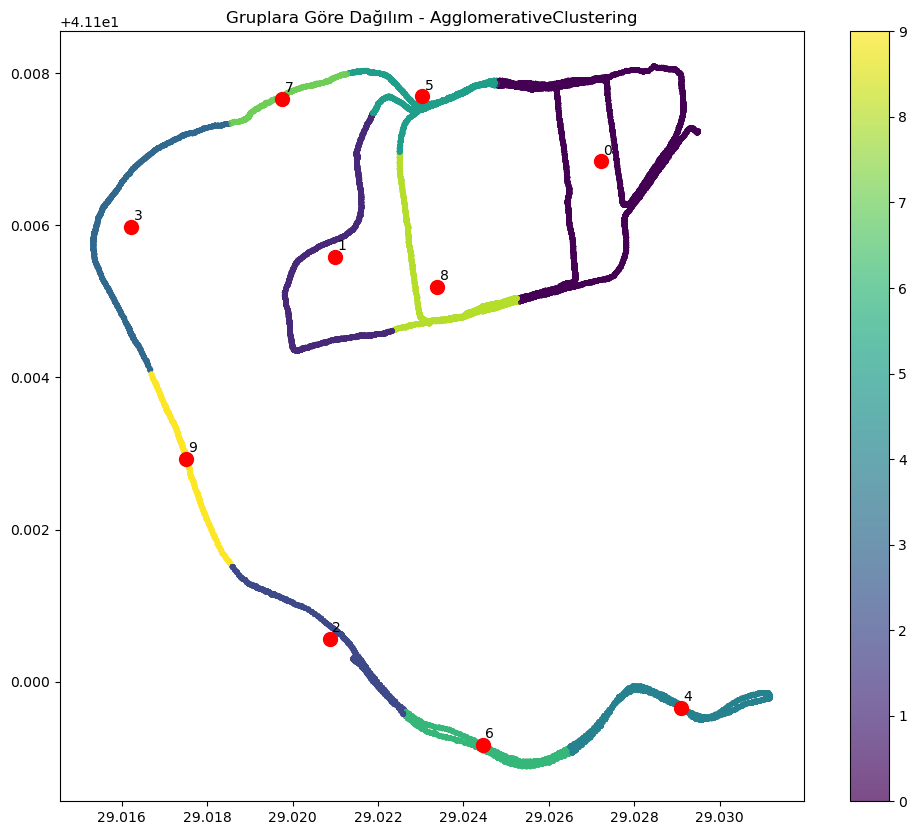

Avg Distance: 151.68017156434044
Max Distance: 224.27852139633922


Avg Distance: 114.45183931503298
Max Distance: 216.36749041907566


Avg Distance: 442.09621364425306
Max Distance: 581.2621603958645


Avg Distance: 383.145728903881
Max Distance: 473.57610863992915


Avg Distance: 280.2864168803867
Max Distance: 337.4942404521427


Avg Distance: 60.60502648502289
Max Distance: 142.31740865877728


Avg Distance: 191.57844634531457
Max Distance: 337.5526017684166


Avg Distance: 189.48398245602237
Max Distance: 280.8477343106572


Avg Distance: 225.4584605141208
Max Distance: 336.4502034148952


Avg Distance: 478.06448327143306
Max Distance: 607.1470609740948




In [41]:
data = pd.read_csv(paths._processed_saha_olcum_dir / "5G_DataSet.csv")
data = data.loc[:, ~data.columns.str.contains('^Unnamed')]

x = data["Longitude"]
y = data["Latitude"]

data = data.drop(columns=["Time"])

n = 10
X = np.concatenate((np.array(x).reshape(1,-1), np.array(y).reshape(1,-1)))
X = X.T

knn_graph = kneighbors_graph(X, 50, include_self=False)
aggc = AgglomerativeClustering(n_clusters=n, linkage= "ward", connectivity = knn_graph).fit(X)

data["aggc_groups"] = aggc.labels_

cluster_centers_aggc = [(data[["Longitude","Latitude"]][data["aggc_groups"]==i]).mean() for i in set(aggc.labels_)]

cluster_centers_aggc_x = np.array(cluster_centers_aggc)[:,:1]
cluster_centers_aggc_y = np.array(cluster_centers_aggc)[:,1:]

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(1, 1, 1)

sc = ax.scatter(
    x,
    y,
    c=aggc.labels_,
    cmap="viridis",
    s=10,
    alpha=0.7
)

ax.scatter(
    cluster_centers_aggc_x,
    cluster_centers_aggc_y,
    s=100,
    c="red",
    
)

for i, (x_, y_) in enumerate(zip(cluster_centers_aggc_x, cluster_centers_aggc_y)):
    ax.annotate(str(i), (x_,y_), textcoords="offset points", xytext=(5, 5), ha='center')
    
ax.set_title("Gruplara Göre Dağılım - AgglomerativeClustering")

cbar = plt.colorbar(sc)

plt.show()

# Setting train-test datasets manually
aggc_train_test = {
    2:[0,1,3,4,5,7,8],
    4:[1,2,3,5,7,8,9,0],
    3:[1,2,4,5,6,8,0],
    6:[1,3,5,7,8,9,0],
    0:[1,2,3,4,6,7,9],
    1:[2,3,4,6,7,9,0],
    7:[1,2,4,6,8,9,0],
    9:[1,4,5,6,7,8,0],
    8:[7,3,9,2,6,4],
    5:[3,9,2,6,4]
}

drop_cols = ["aggc_groups", "Longitude", "Latitude"]

for i in aggc_train_test:
    train, test = data[[True if e in aggc_train_test[i] else False for e in data["aggc_groups"]]], data[data["aggc_groups"]==i]
    
    X_train, X_test = train.drop(columns=drop_cols), test.drop(columns=drop_cols)
    y_train, y_test = train[["Longitude","Latitude"]], test[["Longitude","Latitude"]]

    multioutput_regressor = MultiOutputRegressor(RandomForestRegressor(n_jobs=-1))
    
    multioutput_regressor.fit(X_train, y_train)

    y_pred = multioutput_regressor.predict(X_test)

    distances = haversine_np(y_pred[:,1], y_pred[:,0], y_test["Latitude"], y_test["Longitude"])
    mean_euclidean_error = np.mean(distances)
    
    print("Avg Distance:", mean_euclidean_error)

    max_euclidean_error = np.max(distances)
    print("Max Distance:", max_euclidean_error)
    print("\n")